# 03. Nuclei-derived tissue morphology

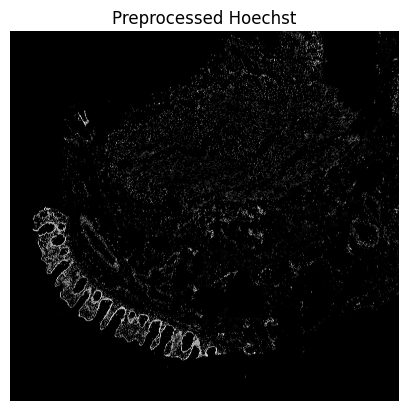

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import exposure, filters, morphology, segmentation

hoechst_roi = tifffile.imread('data/preprocessed_hoechst_roi.tif')

plt.imshow(hoechst_roi, cmap='gray')
plt.title('Preprocessed Hoechst')
plt.axis('off')
plt.show()

In [2]:
lo, hi = np.percentile(hoechst_roi, [1, 99.8])
hoechst_norm = exposure.rescale_intensity(hoechst_roi, in_range=(lo, hi), out_range=(0, 1))


In [3]:
block_size = 1001
offset = -0.03

local_threshold = filters.threshold_local(hoechst_norm, block_size=block_size, offset=offset, method='mean') # gaussian
nuclei = hoechst_norm > local_threshold


In [4]:
tissue_radius = 20

tissue = morphology.dilation(nuclei, morphology.disk(tissue_radius))

In [8]:
min_tissue_area = 8000
tissue = morphology.remove_small_objects(
    tissue,
    max_size=min_tissue_area
)

In [9]:
min_tissue_area = 8000
tissue = morphology.remove_small_holes(
    tissue,
    max_size=min_tissue_area
)

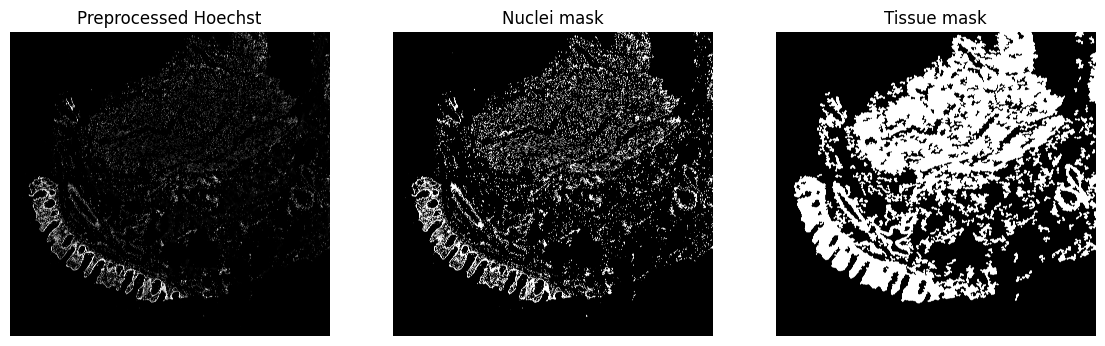

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(hoechst_norm, cmap='gray')
ax[0].set_title('Preprocessed Hoechst')
ax[1].imshow(nuclei, cmap='gray')
ax[1].set_title('Nuclei mask')
ax[2].imshow(tissue, cmap='gray')
ax[2].set_title('Tissue mask')
for a in ax:
    a.axis('off')
plt.show()

In [11]:
marker_positive = nuclei & tissue
marker_positive_area = marker_positive.sum()
tissue_area = tissue.sum()
marker_positive_percent = 100 * marker_positive_area / tissue_area

print('Hoechst-positive area, px:', marker_positive_area)
print('Tissue area, px:', tissue_area)
print('Hoechst-positive area, %:', marker_positive_percent)

Hoechst-positive area, px: 7909644
Tissue area, px: 30511268
Hoechst-positive area, %: 25.923681703428386
